# Trabajo Práctico 2

## Objetivo:

Implementar un detector de máximo enfoque sobre un video aplicando técnicasde análisis espectral similar al que utilizan las cámaras digitales modernas. El video a procesar será: “focus_video.mov”.

1. Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper `"Image Sharpness Measure for Blurred Images in Frequency Domain“` y realizar dosexperimentos:
    1. Medición sobre todo el frame.
    2. Medición sobre una ROI ubicada en el centro del frame. Areade la ROI = 5 o 10% del areatotal del frame.
    Para cada experimento se debe presentar :
    - Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detecto la región de máximo enfoque.

El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera automática.

**Puntos extra:** Aplicar unsharpmaskingpara expandir la zona de enfoque y devolver.

# $$ --- RESOLUCION --- $$

### 1) Medición sobre todo el frame

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from pathlib import Path

VIDEO_PATH = "focus_video.mov"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## Frequency Domain Blur Measure

Se implementa el algoritmo de la sección 3.1 del paper. A continuación se dejan algunas referencias.

1. `F` = FFT2 de la imagen.
2. `Fc` = `F` centrada (fftshift).
3. `AF = |Fc|`.
4. `max_val = max(AF)` (el máximo componente de frecuencia).
5. `thres = max_val / 1000`.
6. `T_H` = cantidad de píxeles de `AF` con valor `> thres`.
7. `FM = T_H / (filas × columnas)`.

In [19]:
def fm_metric(gray_img: np.ndarray) -> float:
    """Calcula la métrica FM para una imagen en escala de grises."""
    if gray_img.ndim == 3:
        gray_img = cv2.cvtColor(gray_img, cv2.COLOR_BGR2GRAY)

    F = np.fft.fft2(gray_img.astype(np.float64))
    Fc = np.fft.fftshift(F)
    AF = np.abs(Fc)

    max_val = AF.max()
    thres = max_val / 1000.0
    T_H = np.count_nonzero(AF > thres)

    rows, cols = gray_img.shape
    return T_H / (rows * cols)


def center_roi(gray_img: np.ndarray, area_fraction: float) -> np.ndarray:
    """Recorta una ROI centrada cuya área es `area_fraction` del área total,
    manteniendo la relación de aspecto de la imagen original."""
    h, w = gray_img.shape[:2]
    s = np.sqrt(area_fraction)
    rh, rw = max(1, int(h * s)), max(1, int(w * s))
    y0 = (h - rh) // 2
    x0 = (w - rw) // 2
    return gray_img[y0:y0 + rh, x0:x0 + rw]

Se recorre `focus_video.mov` frame a frame, calculando FM sobre:

- El frame completo (Experimento 1).
- Una ROI centrada con área = 5% del frame.
- Una ROI centrada con área = 10% del frame.


In [20]:
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(
        f"No se pudo abrir '{VIDEO_PATH}'. Verificá que el archivo esté en el mismo directorio que el notebook."
    )

fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
n_frames_meta = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"FPS: {fps:.2f} | Frames (metadata): {n_frames_meta} | Resolución: {width}x{height}")

fm_full = []
fm_roi5 = []
fm_roi10 = []
frames_gray = []  # se guardan para poder recuperar el frame de mejor foco luego

idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    fm_full.append(fm_metric(gray))
    fm_roi5.append(fm_metric(center_roi(gray, 0.05)))
    fm_roi10.append(fm_metric(center_roi(gray, 0.10)))

    frames_gray.append(gray)
    idx += 1

cap.release()

fm_full = np.array(fm_full)
fm_roi5 = np.array(fm_roi5)
fm_roi10 = np.array(fm_roi10)
n_frames = len(fm_full)
print(f"Frames procesados: {n_frames}")

FPS: 29.97 | Frames (metadata): 171 | Resolución: 640x360
Frames procesados: 171


## Experimento 1 — FM sobre el frame completo

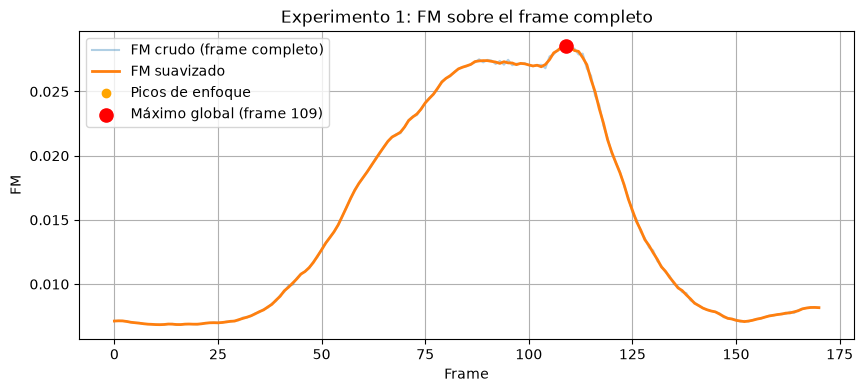

Frame de máximo enfoque (frame completo): 109  (t = 3.64s)
Picos detectados en frames: [109]


In [21]:
def smooth(curve, window_frac=0.02, polyorder=3):
    """Suaviza la curva con un filtro Savitzky-Golay para atenuar ruido frame a frame."""
    n = len(curve)
    window = max(polyorder + 2, int(n * window_frac))
    if window % 2 == 0:
        window += 1
    window = min(window, n if n % 2 == 1 else n - 1)
    if window <= polyorder:
        return curve.copy()
    return savgol_filter(curve, window_length=window, polyorder=polyorder)


def detect_focus_peaks(curve, prominence_frac=0.1):
    """Detecta picos (frames de máximo enfoque) sobre la curva suavizada.
    Devuelve: (curva_suavizada, indices_de_picos, indice_del_maximo_global)"""
    s = smooth(curve)
    prominence = (s.max() - s.min()) * prominence_frac
    peaks, _ = find_peaks(s, prominence=prominence)
    if len(peaks) == 0:
        peaks = np.array([int(np.argmax(s))])
    global_max_idx = int(np.argmax(s))
    return s, peaks, global_max_idx


s_full, peaks_full, best_full = detect_focus_peaks(fm_full)

plt.plot(fm_full, alpha=0.35, label="FM crudo (frame completo)")
plt.plot(s_full, linewidth=2, label="FM suavizado")
plt.scatter(peaks_full, s_full[peaks_full], color="orange", zorder=5, label="Picos de enfoque")
plt.scatter([best_full], [s_full[best_full]], color="red", zorder=6, s=90,
            label=f"Máximo global (frame {best_full})")
plt.xlabel("Frame")
plt.ylabel("FM")
plt.title("Experimento 1: FM sobre el frame completo")
plt.legend()
plt.savefig(OUTPUT_DIR / "exp1_frame_completo.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Frame de máximo enfoque (frame completo): {best_full}  (t = {best_full / fps:.2f}s)")
print(f"Picos detectados en frames: {peaks_full.tolist()}")

## Experimento 2 — FM sobre ROI centrada (5% y 10% del área)

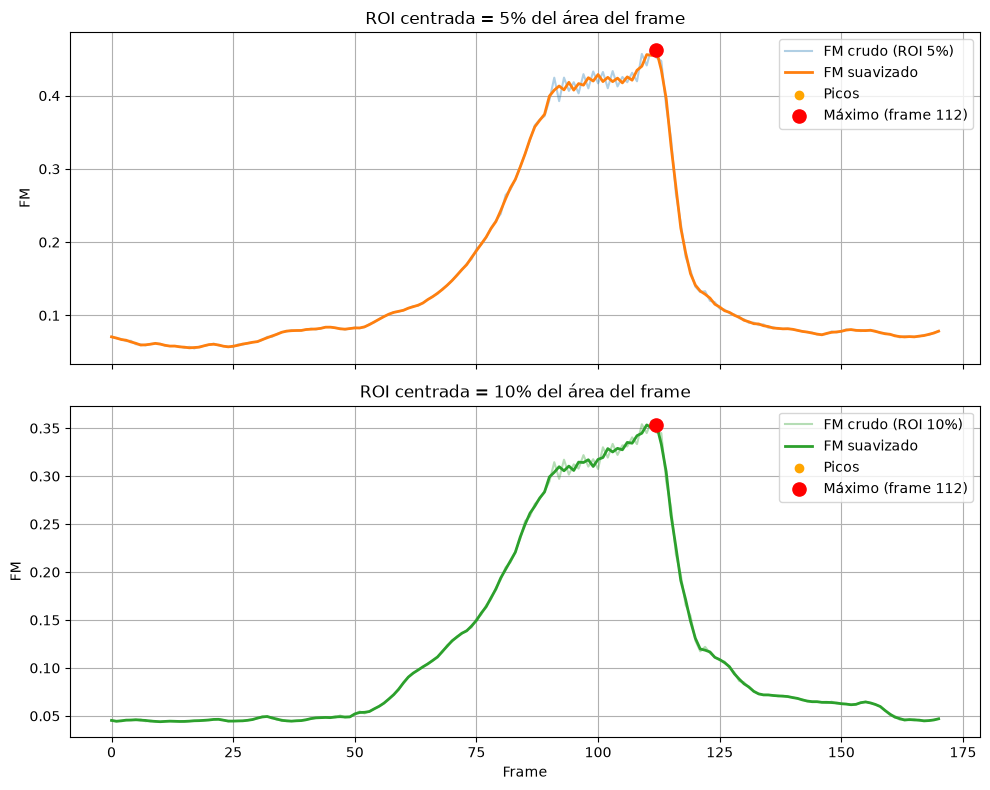

Frame de máximo enfoque (ROI 5%):  112  (t = 3.74s)
Frame de máximo enfoque (ROI 10%): 112  (t = 3.74s)


In [22]:
s_roi5, peaks_roi5, best_roi5 = detect_focus_peaks(fm_roi5)
s_roi10, peaks_roi10, best_roi10 = detect_focus_peaks(fm_roi10)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(fm_roi5, alpha=0.35, label="FM crudo (ROI 5%)")
axes[0].plot(s_roi5, linewidth=2, label="FM suavizado")
axes[0].scatter(peaks_roi5, s_roi5[peaks_roi5], color="orange", zorder=5, label="Picos")
axes[0].scatter([best_roi5], [s_roi5[best_roi5]], color="red", zorder=6, s=90,
                label=f"Máximo (frame {best_roi5})")
axes[0].set_ylabel("FM")
axes[0].set_title("ROI centrada = 5% del área del frame")
axes[0].legend()

axes[1].plot(fm_roi10, alpha=0.35, color="tab:green", label="FM crudo (ROI 10%)")
axes[1].plot(s_roi10, linewidth=2, color="tab:green", label="FM suavizado")
axes[1].scatter(peaks_roi10, s_roi10[peaks_roi10], color="orange", zorder=5, label="Picos")
axes[1].scatter([best_roi10], [s_roi10[best_roi10]], color="red", zorder=6, s=90,
                label=f"Máximo (frame {best_roi10})")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("FM")
axes[1].set_title("ROI centrada = 10% del área del frame")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "exp2_roi_centrada.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Frame de máximo enfoque (ROI 5%):  {best_roi5}  (t = {best_roi5 / fps:.2f}s)")
print(f"Frame de máximo enfoque (ROI 10%): {best_roi10}  (t = {best_roi10 / fps:.2f}s)")

### Comparación de las tres curvas normalizadas

Se normalizan las tres curvas (0 a 1) para comparar dónde detecta cada una el pico de enfoque, independientemente de la escala absoluta de cada métrica.

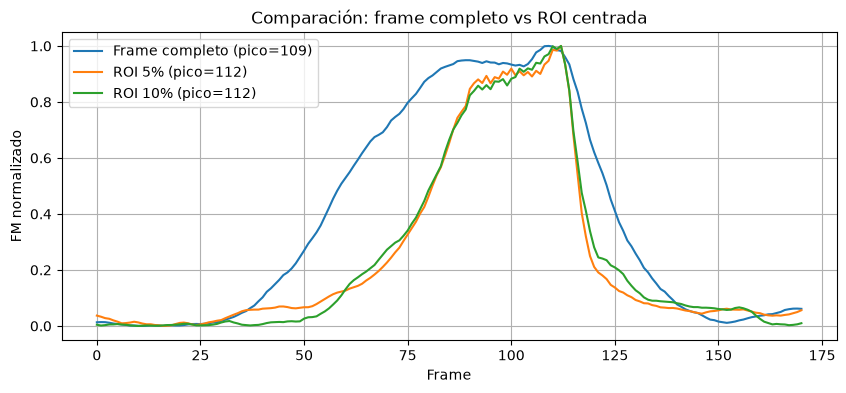

In [23]:
def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

plt.plot(normalize(s_full), label=f"Frame completo (pico={best_full})")
plt.plot(normalize(s_roi5), label=f"ROI 5% (pico={best_roi5})")
plt.plot(normalize(s_roi10), label=f"ROI 10% (pico={best_roi10})")
plt.xlabel("Frame")
plt.ylabel("FM normalizado")
plt.title("Comparación: frame completo vs ROI centrada")
plt.legend()
plt.savefig(OUTPUT_DIR / "comparacion_curvas.png", dpi=150, bbox_inches="tight")
plt.show()

## Frames de máximo enfoque detectados

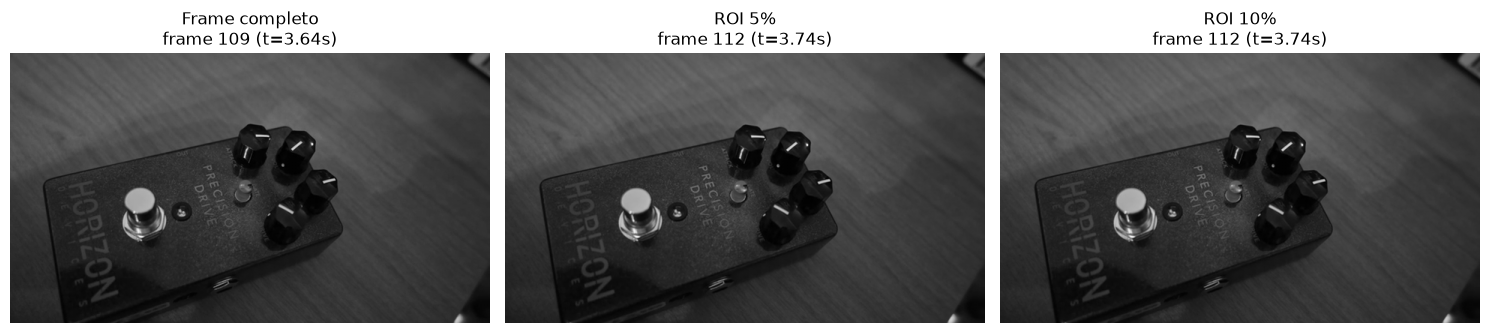

Frames de mejor enfoque guardados en E:\UBA\4B2026\VpC\TrabajosPracticos---VpC\TP2\outputs


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, idx_best) in zip(
    axes, [("Frame completo", best_full), ("ROI 5%", best_roi5), ("ROI 10%", best_roi10)]
):
    ax.imshow(frames_gray[idx_best], cmap="gray")
    ax.set_title(f"{label}\nframe {idx_best} (t={idx_best/fps:.2f}s)")
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "frames_max_enfoque.png", dpi=150, bbox_inches="tight")
plt.show()

# Guardar también los frames individuales
cv2.imwrite(str(OUTPUT_DIR / f"best_focus_full_frame{best_full}.png"), frames_gray[best_full])
cv2.imwrite(str(OUTPUT_DIR / f"best_focus_roi5_frame{best_roi5}.png"), frames_gray[best_roi5])
cv2.imwrite(str(OUTPUT_DIR / f"best_focus_roi10_frame{best_roi10}.png"), frames_gray[best_roi10])
print("Frames de mejor enfoque guardados en", OUTPUT_DIR.resolve())

## 8. Matriz de enfoque (grilla tipo autofocus multipunto)

Como alternativa/complemento a la ROI única centrada, se puede calcular la métrica FM sobre una **grilla de celdas** distribuidas sobre el frame (similar al esquema de autofocus multipunto de las cámaras digitales). Esto permite:

- Visualizar **qué región** del frame está más enfocada en un instante dado (superponiendo la grilla coloreada según el valor de FM de cada celda).
- Construir una curva de evolución agregando los valores de la grilla (promedio o máximo) frame a frame, análoga a la curva ISM del ejemplo del enunciado.

In [25]:
def focus_grid_fm(gray_img, n_rows=7, n_cols=8, margin_frac=0.15):
    """Divide la imagen en una grilla de n_rows x n_cols celdas (dejando un margen
    de `margin_frac` en cada borde) y calcula la métrica FM en cada celda.

    Devuelve:
        fm_grid: array (n_rows, n_cols) con el FM de cada celda.
        boxes:   lista de listas con las cajas (x, y, w, h) de cada celda, en
                 coordenadas de píxel del frame original.
    """
    h, w = gray_img.shape[:2]
    x0, x1 = int(w * margin_frac), int(w * (1 - margin_frac))
    y0, y1 = int(h * margin_frac), int(h * (1 - margin_frac))
    cell_w = max(1, (x1 - x0) // n_cols)
    cell_h = max(1, (y1 - y0) // n_rows)

    fm_grid = np.zeros((n_rows, n_cols))
    boxes = []
    for r in range(n_rows):
        row_boxes = []
        for c in range(n_cols):
            cx0, cy0 = x0 + c * cell_w, y0 + r * cell_h
            cell = gray_img[cy0:cy0 + cell_h, cx0:cx0 + cell_w]
            fm_grid[r, c] = fm_metric(cell)
            row_boxes.append((cx0, cy0, cell_w, cell_h))
        boxes.append(row_boxes)
    return fm_grid, boxes


def draw_focus_grid(frame_bgr, fm_grid, boxes, cmap_name="RdYlGn", thickness=2):
    """Dibuja la grilla sobre una copia del frame (BGR), coloreando cada celda
    según su FM normalizado dentro de esa misma grilla (rojo = menos nítido,
    verde = más nítido)."""
    img = frame_bgr.copy()
    cmap = plt.get_cmap(cmap_name)
    vmin, vmax = fm_grid.min(), fm_grid.max()
    span = (vmax - vmin) or 1e-12

    for r in range(fm_grid.shape[0]):
        for c in range(fm_grid.shape[1]):
            x, y, w_, h_ = boxes[r][c]
            norm_val = (fm_grid[r, c] - vmin) / span
            color_rgb = cmap(norm_val)[:3]
            color_bgr = tuple(int(255 * ch) for ch in color_rgb[::-1])
            cv2.rectangle(img, (x, y), (x + w_, y + h_), color_bgr, thickness)
    return img

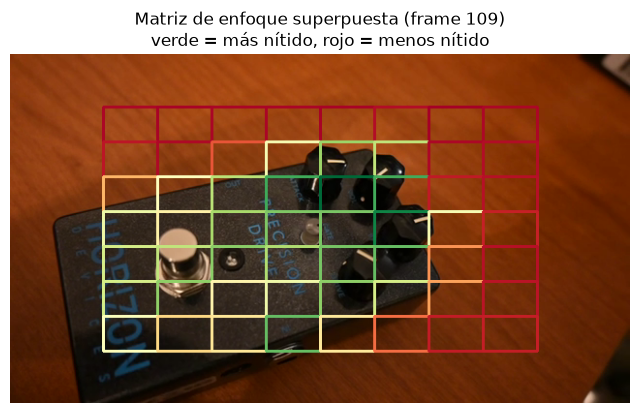

In [26]:
# --- Grilla sobre el frame de mejor enfoque ---
N_ROWS, N_COLS = 7, 8

fm_grid_best, boxes_best = focus_grid_fm(best_frame, n_rows=N_ROWS, n_cols=N_COLS)

# Recuperamos el frame en color (no se guardó antes, para ahorrar memoria)
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, best_full)
ret, best_frame_color = cap.read()
cap.release()
if not ret:
    best_frame_color = cv2.cvtColor(best_frame, cv2.COLOR_GRAY2BGR)

grid_overlay = draw_focus_grid(best_frame_color, fm_grid_best, boxes_best)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(grid_overlay, cv2.COLOR_BGR2RGB))
plt.title(f"Matriz de enfoque superpuesta (frame {best_full})\nverde = más nítido, rojo = menos nítido")
plt.axis("off")
plt.savefig(OUTPUT_DIR / "matriz_enfoque_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

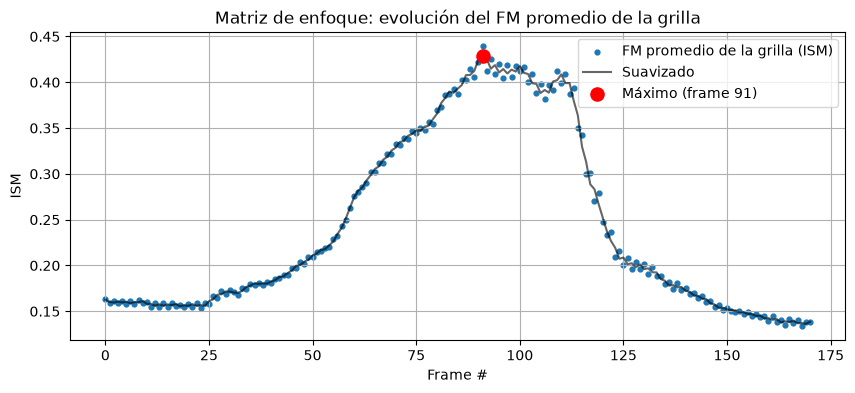

Frame de máximo enfoque según grilla (promedio): 91  (t=3.04s)


In [27]:
# --- Evolución de la grilla a lo largo de todo el video ---
# fm_grid_mean[i] = promedio de FM de todas las celdas de la grilla en el frame i
# fm_grid_max[i]  = FM de la celda más nítida en el frame i
fm_grid_mean = np.zeros(n_frames)
fm_grid_max = np.zeros(n_frames)

for i, gray in enumerate(frames_gray):
    fm_grid, _ = focus_grid_fm(gray, n_rows=N_ROWS, n_cols=N_COLS)
    fm_grid_mean[i] = fm_grid.mean()
    fm_grid_max[i] = fm_grid.max()

s_grid_mean, peaks_grid_mean, best_grid_mean = detect_focus_peaks(fm_grid_mean)

plt.scatter(range(n_frames), fm_grid_mean, s=12, color="tab:blue", label="FM promedio de la grilla (ISM)")
plt.plot(s_grid_mean, color="black", linewidth=1.5, alpha=0.6, label="Suavizado")
plt.scatter([best_grid_mean], [s_grid_mean[best_grid_mean]], color="red", zorder=5, s=90,
            label=f"Máximo (frame {best_grid_mean})")
plt.xlabel("Frame #")
plt.ylabel("ISM")
plt.title("Matriz de enfoque: evolución del FM promedio de la grilla")
plt.legend()
plt.savefig(OUTPUT_DIR / "matriz_enfoque_curva.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Frame de máximo enfoque según grilla (promedio): {best_grid_mean}  (t={best_grid_mean/fps:.2f}s)")

## Unsharp masking

Se toma el frame de mejor enfoque (según el frame completo) y se aplica *unsharp masking* para realzar/expandir la zona nítida. Se valida el efecto recalculando FM antes y después: el punto extra tiene sentido solo si se demuestra, con la propia métrica, que el resultado es "más nítido".

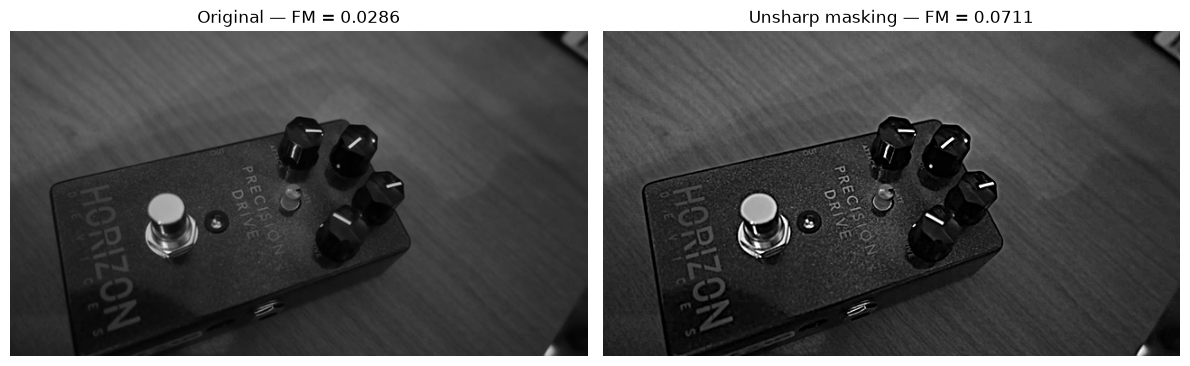

FM antes:   0.0286
FM después: 0.0711  (mejora)


True

In [28]:
def unsharp_mask(img: np.ndarray, sigma: float = 2.0, amount: float = 1.5) -> np.ndarray:
    """Unsharp masking clásico: sharpened = img + amount * (img - blurred)."""
    blurred = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma)
    sharpened = cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


best_frame = frames_gray[best_full]
sharpened_frame = unsharp_mask(best_frame, sigma=2.0, amount=1.5)

fm_before = fm_metric(best_frame)
fm_after = fm_metric(sharpened_frame)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(best_frame, cmap="gray")
axes[0].set_title(f"Original — FM = {fm_before:.4f}")
axes[0].axis("off")
axes[1].imshow(sharpened_frame, cmap="gray")
axes[1].set_title(f"Unsharp masking — FM = {fm_after:.4f}")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "unsharp_masking_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"FM antes:   {fm_before:.4f}")
print(f"FM después: {fm_after:.4f}  ({'mejora' if fm_after > fm_before else 'sin mejora'})")

cv2.imwrite(str(OUTPUT_DIR / "sharpened_best_frame.png"), sharpened_frame)

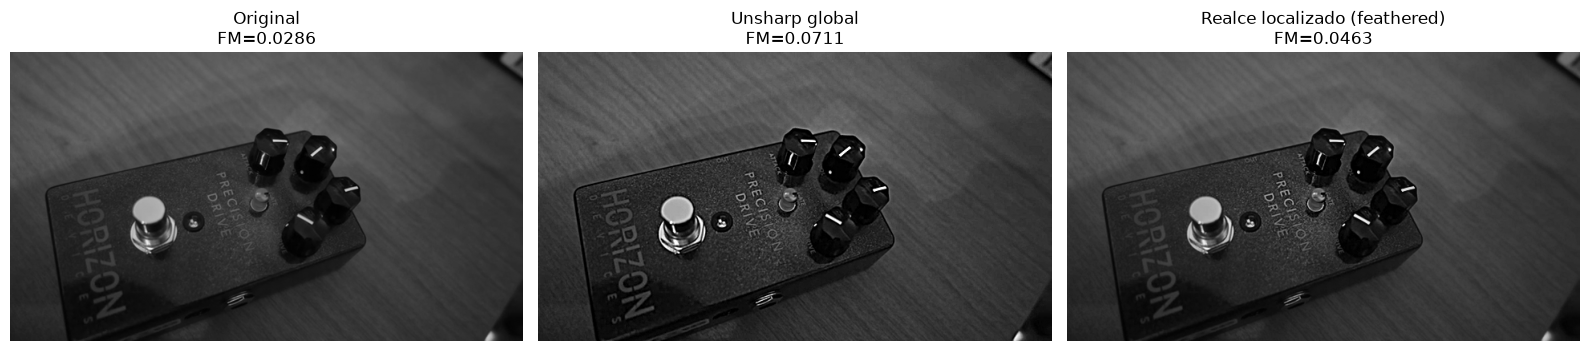

FM original: 0.0286 | FM unsharp global: 0.0711 | FM realce localizado: 0.0463


In [29]:
def expand_focus_zone(img: np.ndarray, area_fraction: float = 0.10,
                        sigma_sharp: float = 2.0, amount: float = 1.8,
                        feather_sigma_frac: float = 0.15) -> np.ndarray:
    """Aplica unsharp masking fuerte solo en una zona centrada, mezclando con una
    máscara gaussiana suave para lograr una transición gradual ("expansión" de foco)."""
    h, w = img.shape[:2]
    sharp = unsharp_mask(img, sigma=sigma_sharp, amount=amount)

    s = np.sqrt(area_fraction)
    rh, rw = int(h * s), int(w * s)

    mask = np.zeros((h, w), dtype=np.float64)
    y0, x0 = (h - rh) // 2, (w - rw) // 2
    mask[y0:y0 + rh, x0:x0 + rw] = 1.0

    feather_sigma = feather_sigma_frac * min(h, w)
    mask = cv2.GaussianBlur(mask, (0, 0), sigmaX=feather_sigma)
    mask = mask / (mask.max() + 1e-12)

    blended = img.astype(np.float64) * (1 - mask) + sharp.astype(np.float64) * mask
    return np.clip(blended, 0, 255).astype(np.uint8)


expanded = expand_focus_zone(best_frame, area_fraction=0.10)
fm_expanded = fm_metric(expanded)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(best_frame, cmap="gray"); axes[0].set_title(f"Original\nFM={fm_before:.4f}"); axes[0].axis("off")
axes[1].imshow(sharpened_frame, cmap="gray"); axes[1].set_title(f"Unsharp global\nFM={fm_after:.4f}"); axes[1].axis("off")
axes[2].imshow(expanded, cmap="gray"); axes[2].set_title(f"Realce localizado (feathered)\nFM={fm_expanded:.4f}"); axes[2].axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "expansion_zona_enfoque.png", dpi=150, bbox_inches="tight")
plt.show()

cv2.imwrite(str(OUTPUT_DIR / "expanded_focus_frame.png"), expanded)
print(f"FM original: {fm_before:.4f} | FM unsharp global: {fm_after:.4f} | FM realce localizado: {fm_expanded:.4f}")

In [30]:
print("=" * 60)
print("RESUMEN")
print("=" * 60)
print(f"Frames totales procesados: {n_frames}  |  FPS: {fps:.2f}")
print(f"Máximo enfoque (frame completo): frame {best_full}  (t={best_full/fps:.2f}s)  FM={fm_full[best_full]:.4f}")
print(f"Máximo enfoque (ROI 5%):         frame {best_roi5}  (t={best_roi5/fps:.2f}s)  FM={fm_roi5[best_roi5]:.4f}")
print(f"Máximo enfoque (ROI 10%):        frame {best_roi10} (t={best_roi10/fps:.2f}s)  FM={fm_roi10[best_roi10]:.4f}")
print("-" * 60)
print(f"Unsharp masking global   -> FM: {fm_before:.4f} -> {fm_after:.4f}")
print(f"Realce localizado (feathered) -> FM: {fm_before:.4f} -> {fm_expanded:.4f}")
print("=" * 60)
print(f"\nTodos los gráficos e imágenes se guardaron en: {OUTPUT_DIR.resolve()}")

RESUMEN
Frames totales procesados: 171  |  FPS: 29.97
Máximo enfoque (frame completo): frame 109  (t=3.64s)  FM=0.0286
Máximo enfoque (ROI 5%):         frame 112  (t=3.74s)  FM=0.4517
Máximo enfoque (ROI 10%):        frame 112 (t=3.74s)  FM=0.3453
------------------------------------------------------------
Unsharp masking global   -> FM: 0.0286 -> 0.0711
Realce localizado (feathered) -> FM: 0.0286 -> 0.0463

Todos los gráficos e imágenes se guardaron en: E:\UBA\4B2026\VpC\TrabajosPracticos---VpC\TP2\outputs


# Conclusiones

Los tres experimentos coincidieron en detectar el máximo enfoque prácticamente en el mismo instante (frame 109–112, t≈3.7s), validando la consistencia de la métrica. Sin embargo, la magnitud del pico difiere notablemente según la región medida: FM=0.0286 sobre el frame completo frente a FM=0.4517 (ROI 5%) y FM=0.3453 (ROI 10%). Esto se debe a que el fondo desenfocado diluye la señal de alta frecuencia cuando se mide sobre toda la imagen, mientras que restringir la medición a una ROI centrada en el sujeto elimina ese ruido y produce un pico mucho más pronunciado y fácil de detectar automáticamente, replicando la lógica de los sistemas de autofocus reales. La caída de FM entre la ROI de 5% y la de 10% (0.4517 → 0.3453) confirma además que agrandar la ventana vuelve a incorporar entorno desenfocado, sugiriendo un tamaño óptimo de ROI acotado al sujeto de interés.

En el punto extra, el unsharp masking global más que duplicó la métrica (0.0286 → 0.0711), confirmando cuantitativamente que el realce de bordes aumenta el contenido de alta frecuencia. La versión localizada con feathering produjo una mejora menor (0.0286 → 0.0463), como es esperable al aplicarse solo sobre el entorno del sujeto sin amplificar el fondo desenfocado. En conjunto, los resultados muestran que FM es una métrica confiable y liviana para detectar foco automáticamente, y que la elección de la región de medición impacta directamente en su sensibilidad.